In [2]:
import numpy as np
import networkx as nx

import os

%load_ext autoreload
%autoreload 2

In [46]:
results_dir = "erdos_renyi_n=100_p=0.3_num_runs_2"
os.mkdir(results_dir)

In [48]:
seed = 42
G = nx.erdos_renyi_graph(n=100, p=0.3, seed=seed)

graph_arr = np.empty(1, dtype=object)
graph_arr[0] = G
np.save(f"{results_dir}/erdos_renyi_n=100_p=0.3.npy", graph_arr)

In [49]:
from Qommunity.samplers.hierarchical.advantage_sampler import AdvantageSampler
from Qommunity.iterative_searcher import IterativeSearcher

In [50]:
adv_sampler = AdvantageSampler(G, num_reads=100, version="Advantage_system6.4", region="na-west-1", use_clique_embedding=True, elapse_times=True, return_metadata=True)
it_searcher = IterativeSearcher(adv_sampler)

In [51]:
results = it_searcher.run_with_sampleset_info(num_runs=2, saving_path=f"{results_dir}/", return_metadata=True)

100%|██████████| 2/2 [00:32<00:00, 16.15s/it]


Just to remember what the returned data is:

In [ ]:
[info_field for info_field in results.dtype.names]

['communities',
 'modularity',
 'time',
 'division_tree',
 'division_modularities',
 'samplesets_data']

Save it somewhere easier

In [142]:
communities = results.communities
modularities = results.modularity
division_modularities = results.division_modularities
division_trees = results.division_tree
times = results.time
samplesets_datas = results.samplesets_data

Here every entry in the array is for the subsequent run:

In [60]:
print(f"Number of runs: {len(results)}")
first_run_data = results[0]
second_run_data= results[1]

Number of runs: 2


The structure of results:

In [81]:
print(f"The first hierarchical run took: {first_run_data.time:.2f} seconds")
print(f"This value can also be accessed like this: {times[0]:.2f} seconds")

print(f"The final modularity from the second run is: {second_run_data.modularity:.4f} == {modularities[1]:.4f}")

from dendro import Dendrogram

print(f"Dendrogram can be made: {Dendrogram(G, communities[0], division_modularities[0], division_tree=[0])}")

The first hierarchical run took: 14.88 seconds
This value can also be accessed like this: 14.88 seconds
The final modularity from the second run is: 0.1289 == 0.1289
Dendrogram can be made: <dendro.dendro.Dendrogram object at 0x0000016235CDABD0>


Let's focus on samplesets data:

In [103]:
from Qommunity.searchers.utils import HierarchicalRunMetadata
from dataclasses import fields

print("A class with lists")
fields(HierarchicalRunMetadata)

A class with lists


(Field(name='dwave_sampleset_metadata',type=<class 'numpy.rec.recarray'>,default=<dataclasses._MISSING_TYPE object at 0x0000016186FF8A90>,default_factory=<dataclasses._MISSING_TYPE object at 0x0000016186FF8A90>,init=False,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='time_measurements',type=<class 'numpy.rec.recarray'>,default=<dataclasses._MISSING_TYPE object at 0x0000016186FF8A90>,default_factory=<dataclasses._MISSING_TYPE object at 0x0000016186FF8A90>,init=False,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='dwave_sampleset',type=typing.List[typing.Dict[str, typing.Any]],default=<dataclasses._MISSING_TYPE object at 0x0000016186FF8A90>,default_factory=<dataclasses._MISSING_TYPE object at 0x0000016186FF8A90>,init=False,repr=True,hash=None,compare=True,metadata=mappingproxy({}),kw_only=False,_field_type=_FIELD),
 Field(name='timing',type=typing.List[typing.Dict[str, 

In [116]:
print(f"There were {len(samplesets_datas)} hierarchical runs\n")
for run, hierarchical_data in enumerate(samplesets_datas):
    print(f"Iter: {run}: there were {len(hierarchical_data)} subproblems submitted to DWave")
    # All of the above are lists
    # THESE TWO WERE IN PREVIOUS EXPS
    dwave_original_samplesets = hierarchical_data.dwave_sampleset_metadata #  QPU access times in here, and the rest of quantum times - WERE IN PREVIOUS EXPS
    custom_timing_measurements = hierarchical_data.time_measurements # Perf_counter times of embeddings and .sample function - WERE IN PREVIOUS EXPS

    # THESE ARE NEW (some redundant - timings)
    dwave_sampleset_metadatas= hierarchical_data.dwave_sampleset # Whole DWave SampleSet class with 100 (#num_reads) elements for each entry in this list
    timings = hierarchical_data.timing
    problem_ids = hierarchical_data.problem_id
    community_hashes = hierarchical_data.community_hash # To identify communities with ordinal numbers - for tree structure identifying
    communities = hierarchical_data.community # For tree structure identifying
    chain_strenghts = hierarchical_data.chain_strength
    chain_break_fractions = hierarchical_data.chain_break_fraction
    embeddings = hierarchical_data.embedding
    warning_msgs = hierarchical_data.warnings

    for i, timing in enumerate(timings):
        print(f"{i} suproblem (no order of division yet): Quantum timings {timing}")

    for i, cbs in enumerate(chain_break_fractions):
        print(f"CBF: {cbs} in suproblem {i}") 


There were 2 hierarchical runs

Iter: 0: there were 7 subproblems submitted to DWave
0 suproblem (no order of division yet): Quantum timings {'qpu_sampling_time': 16486.0, 'qpu_anneal_time_per_sample': 20.0, 'qpu_readout_time_per_sample': 124.28, 'qpu_access_time': 32416.36, 'qpu_access_overhead_time': 1099.64, 'qpu_programming_time': 15930.36, 'qpu_delay_time_per_sample': 20.58, 'post_processing_overhead_time': 42.0, 'total_post_processing_time': 42.0}
1 suproblem (no order of division yet): Quantum timings {'qpu_sampling_time': 11080.0, 'qpu_anneal_time_per_sample': 20.0, 'qpu_readout_time_per_sample': 70.22, 'qpu_access_time': 27010.76, 'qpu_access_overhead_time': 2059.24, 'qpu_programming_time': 15930.76, 'qpu_delay_time_per_sample': 20.58, 'post_processing_overhead_time': 1.0, 'total_post_processing_time': 1.0}
2 suproblem (no order of division yet): Quantum timings {'qpu_sampling_time': 8368.0, 'qpu_anneal_time_per_sample': 20.0, 'qpu_readout_time_per_sample': 43.1, 'qpu_access_t

Having fresh (not recovered from saved files) is cool, because it has some dwave properties (full "SampleSet" DWave class properties) and can be played with dwave.inspector

In [118]:
import dwave.inspector

dwave.inspector.show(results[0].samplesets_data.dwave_sampleset[0])

Serving Inspector on http://127.0.0.1:18000/?problemId=0119af05-2ff3-4741-8e8d-28cb52d6804b

'http://127.0.0.1:18000/?problemId=0119af05-2ff3-4741-8e8d-28cb52d6804b'

How to reload data from dir

In [ ]:
from searchers.utils import HierarchicalRunMetadata
from dataclasses import fields


field_names = [f.name for f in fields(HierarchicalRunMetadata)]
sampleset_metadatas = []

num_runs = 2

for run in range(num_runs):
    hierarchical_run_metadata = HierarchicalRunMetadata.load_from_files(f"{results_dir}/_iter_{run}")
    sampleset_metadatas.append(hierarchical_run_metadata)

Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
DWave sampleset info loaded.
Embeddings info loaded
Could not load dwave_sampleset: EmbeddedStructure is immutable
Could not load embedding: EmbeddedStructure is immutable
DWave sampleset info loaded.
Embeddings info loaded


In [141]:
import numpy as np


communities = np.load(f"{results_dir}/_communities.npy", allow_pickle=True)
modularities = np.load(f"{results_dir}/_modularities.npy", allow_pickle=True)
division_modularities = np.load(f"{results_dir}/_division_modularities.npy", allow_pickle=True)
times = np.load(f"{results_dir}/_times.npy", allow_pickle=True)

### Let's stick to fresh data

In [143]:
communities = results.communities
modularities = results.modularity
division_modularities = results.division_modularities
division_trees = results.division_tree
times = results.time
samplesets_datas = results.samplesets_data

In [162]:
# First iterative run (#num_runs)
samplesets_datas[0].dwave_sampleset_metadata # Quantum times of 7 subproblems
samplesets_datas[0].dwave_sampleset # DWave original SampleSet clases (#num_reads)
samplesets_datas[0].problem_id # DWave Leap problem id for futherh identification
samplesets_datas[0].chain_strength # Chain_strenghts used in subproblems
samplesets_datas[0].chain_break_fraction # Chain break fractions in each subproblem
samplesets_datas[0].chain_break_method # Chain break method

['majority_vote',
 'majority_vote',
 'majority_vote',
 'majority_vote',
 'majority_vote',
 'majority_vote',
 'majority_vote']

In [163]:
mods = []
cbf_max = []
cbf_avg = []
non_zero_cbfs = []
chain_strengths = []
comms_lens = []
energies = []
non_zero_cbf_indices = [] # Hierarchical division in which the CBF was non-zero

for idx, sm in enumerate(sampleset_metadatas):
    cbfs = np.array(sm.chain_break_fraction)
    non_zero_cbfs_idxs = np.where(cbfs > 0)
    cbf_max.append(cbfs.max())
    cbf_avg.append(cbfs.mean())
    non_zero_cbfs.append(cbfs[non_zero_cbfs_idxs])
    non_zero_cbf_indices.append(non_zero_cbfs_idxs)

    chain_strengths.append(np.nanmean(np.array(sm.chain_strength, dtype=float)))
    mods.append(modularities[idx])
    comms_lens.append(communities[idx])

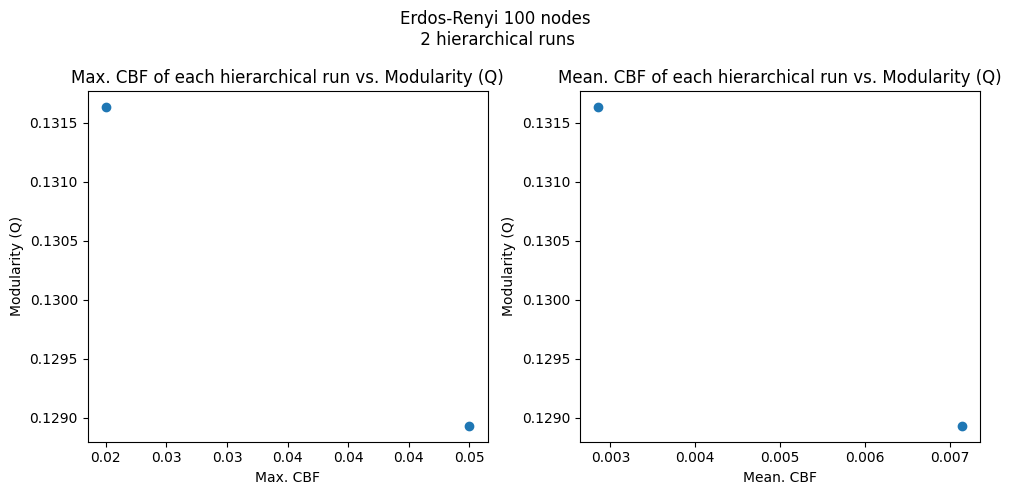

In [167]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Erdos-Renyi 100 nodes\n 2 hierarchical runs")

ax[0].scatter(cbf_max, mods)
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

ax[1].scatter(cbf_avg, mods)
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of each hierarchical run vs. Modularity (Q)");

ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

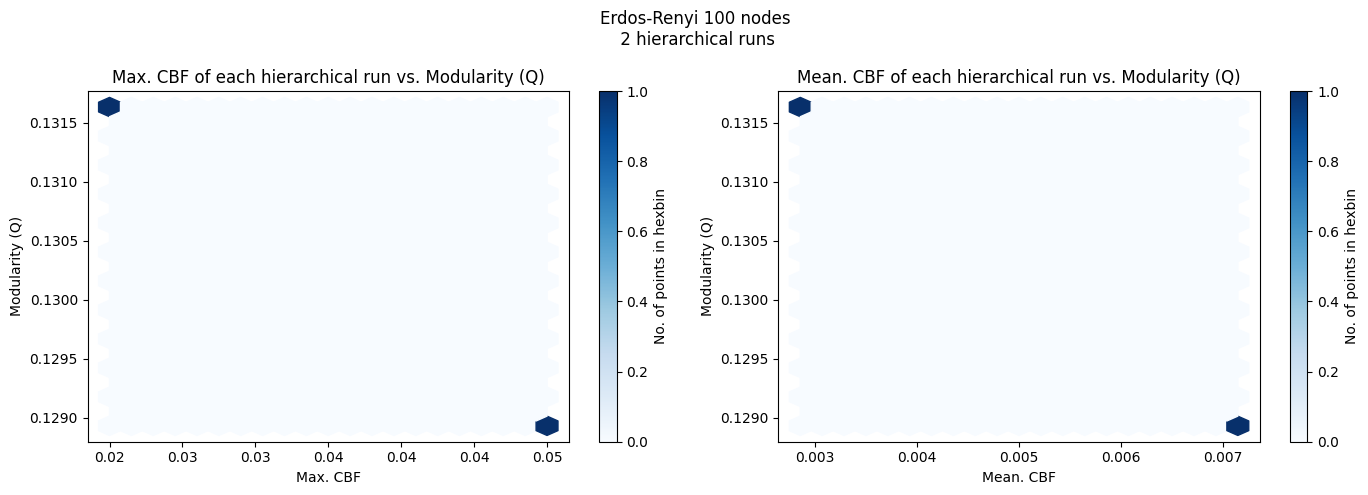

In [170]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Erdos-Renyi 100 nodes\n 2 hierarchical runs")

hb_0 = ax[0].hexbin(cbf_max, mods, cmap="Blues", gridsize=20)
cb = fig.colorbar(hb_0, ax=ax[0])
cb.set_label("No. of points in hexbin")
ax[0].set_ylabel("Modularity (Q)")
ax[0].set_xlabel("Max. CBF")
ax[0].set_title("Max. CBF of each hierarchical run vs. Modularity (Q)");

hb_1 = ax[1].hexbin(cbf_avg, mods, cmap="Blues", gridsize=20)
cb = fig.colorbar(hb_1, ax=ax[1])
cb.set_label("No. of points in hexbin")
ax[1].set_ylabel("Modularity (Q)")
ax[1].set_xlabel("Mean. CBF")
ax[1].set_title("Mean. CBF of each hierarchical run vs. Modularity (Q)");

ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
# ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()

## Before your Python kernel cache (as long as you do not restart the kernel), you can access some DWave data from your cache

In [172]:
from dwave.inspector.storage import get_problem, problemdata_bag, problemdata

In [176]:
problem_ids = {}
energies = {}
qbits_involved = {}
mean_energies = {}
stds = {}
min_energies = {}
max_energies = {}
for run, sm in enumerate(sampleset_metadatas):
    problem_ids[run] = sm.problem_id
    en = []
    qbits = []
    me = []
    std = []
    for problem_id in sm.problem_id:
        pd = get_problem(problem_id=problem_id)
        en.append(pd.response.energies[0])
        qbits.append(len(pd.response.sampleset.variables))
        me.append(pd.response.sampleset.record.energy.mean())
        std.append(pd.response.sampleset.record.energy.std())
    energies[run] = en
    qbits_involved[run] = qbits
    mean_energies[run] = me
    stds[run] = std

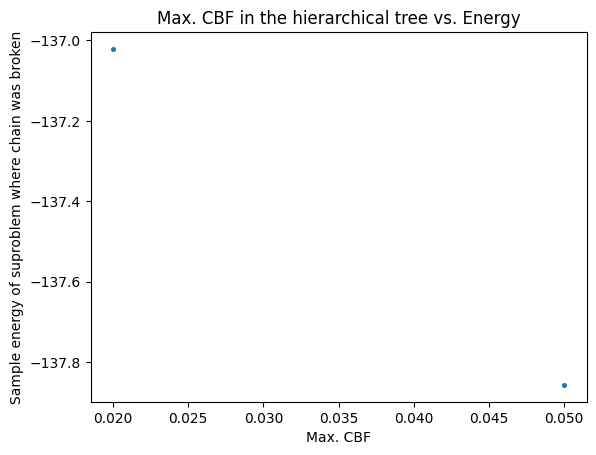

In [178]:
import matplotlib.pyplot as plt


plt.scatter(cbf_max, [v[0] for v in mean_energies.values()], s=7)
# plt.errorbar(cbf_max, [v[0] for v in mean_energies.values()], yerr=[v[0] for v in stds.values()])
# plt.yscale("log")
plt.ylabel("Sample energy of suproblem where chain was broken")
plt.xlabel("Max. CBF")
plt.title("Max. CBF in the hierarchical tree vs. Energy");

In [68]:
from utils import recover_ordering, plot_tree, get_extended_nodes

In [186]:
nodes, root = recover_ordering(G, division_trees[0])